In [53]:
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
athlete_events = pd.read_csv("data/athlete_events.csv")
noc_regions = pd.read_csv("data/noc_regions.csv", low_memory=False)

paris_medals = pd.read_csv("data/medals.csv")

C:\Users\catri\AppData\Local\Temp\ipykernel_20144\520680672.py:1: DtypeWarning: Columns (0: medal) have mixed types. Specify dtype option on import or set low_memory=False.
  athlete_events = pd.read_csv("data/athlete_events.csv")


In [55]:
athlete_events = athlete_events.dropna(subset=["medal"])

In [56]:
df = athlete_events.merge(
    noc_regions,
    left_on="country_noc",
    right_on="noc",
    how="left"
)

In [57]:
print(df.columns)

Index(['edition', 'edition_id', 'country_noc', 'sport', 'event', 'result_id',
       'athlete', 'athlete_id', 'position', 'medal', 'is_team_sport', 'noc',
       'name'],
      dtype='str')


In [58]:
df_unique = df.drop_duplicates(
    subset=["edition", "event", "country_noc", "medal"]
)

In [59]:
df_unique["season"] = df_unique["edition"].str.extract("(Summer|Winter)")

In [60]:
print(df_unique["season"].unique())

<StringArray>
['Winter', 'Summer', nan]
Length: 3, dtype: str


In [61]:
summer = df_unique[df_unique["season"] == "Summer"]
winter = df_unique[df_unique["season"] == "Winter"]

In [62]:
summer_medals = (
    summer.groupby("name")
    .size()
    .reset_index(name="total_medals")
    .sort_values("total_medals", ascending=False)
)

In [63]:
winter_medals = (
    winter.groupby("name")
    .size()
    .reset_index(name="total_medals")
    .sort_values("total_medals", ascending=False)
)

In [66]:
paris_medals = (
    paris_medals.groupby("country")
    .size()
    .reset_index(name="total_medals")
)

In [67]:
paris_medals = paris_medals.rename(columns={"country": "name"})

In [68]:
summer_medals = (
    pd.concat([summer_medals, paris_medals])
    .groupby("name", as_index=False)
    .sum()
)

summer_medals = summer_medals.sort_values(
    "total_medals",
    ascending=False
)

In [69]:
total_medals = (
    df_unique.groupby("name")
    .size()
    .reset_index(name="total_medals")
    .sort_values("total_medals", ascending=False)
)

In [70]:
top50_summer = summer_medals.head(50)
top50_winter = winter_medals.head(50)
top50_total = total_medals.head(50)

In [71]:
def plot_top50(df, title):

    plt.figure(figsize=(10,12))

    plt.barh(df["name"], df["total_medals"])

    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Total de medalhas")

    plt.tight_layout()

    plt.show()

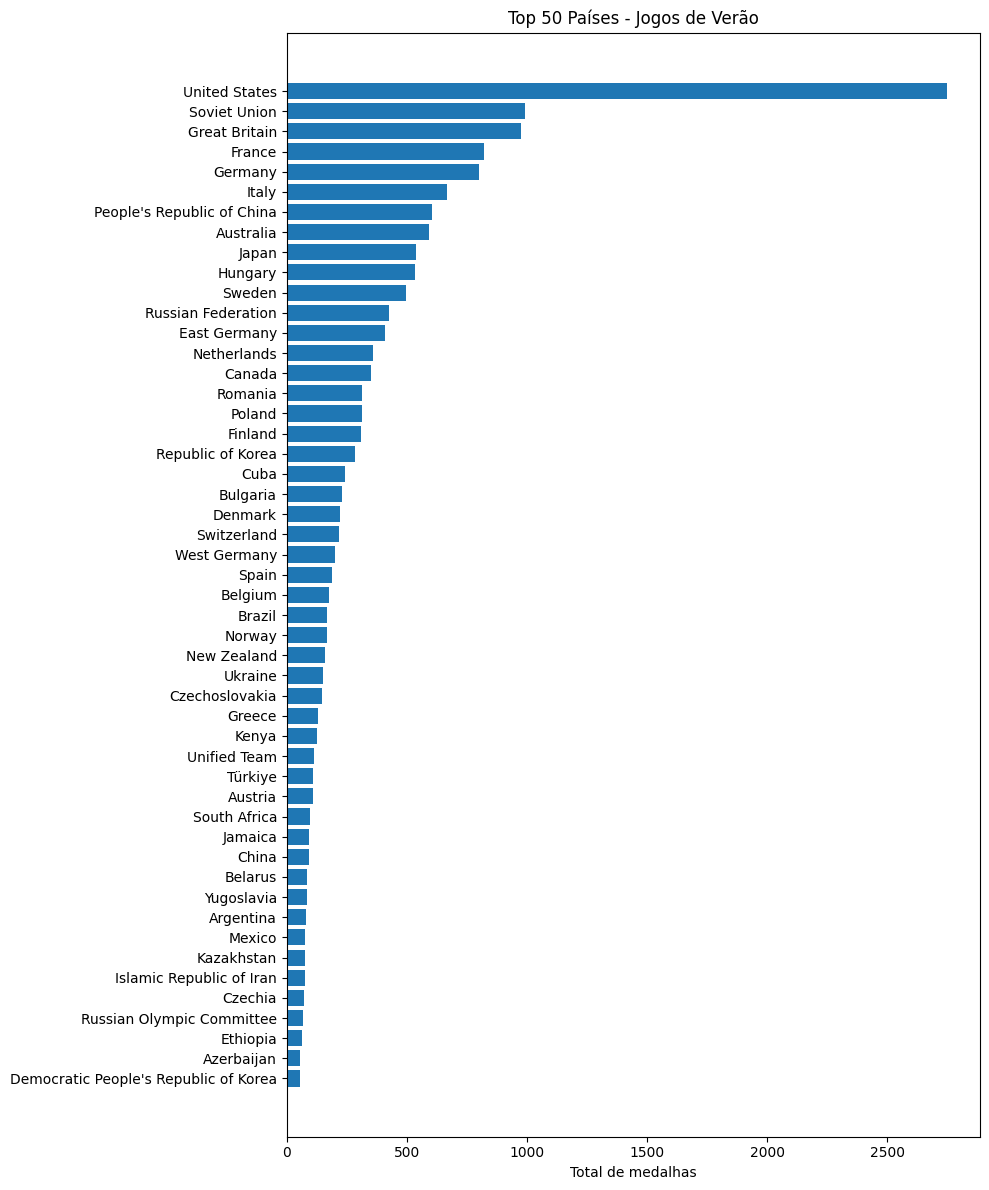

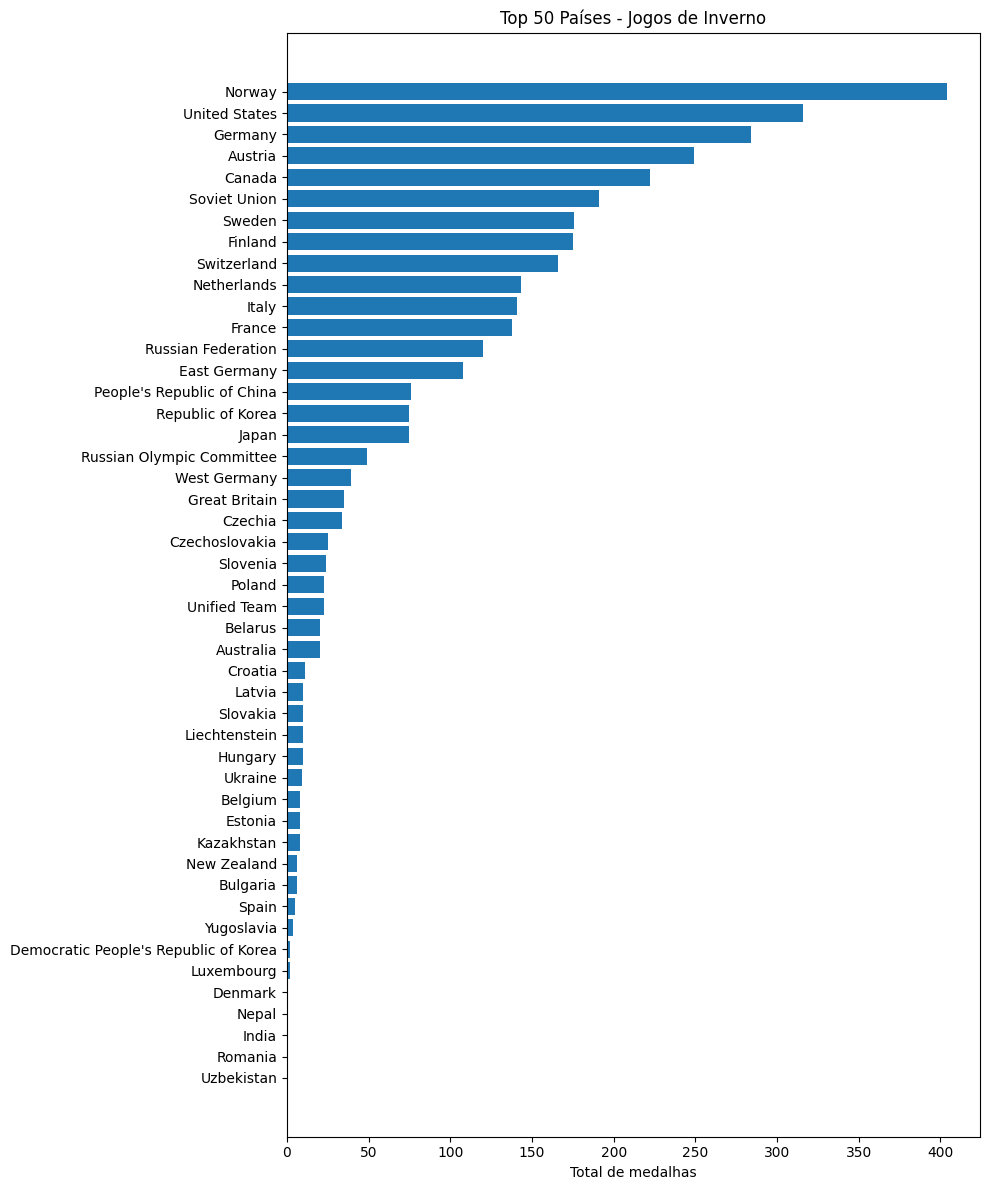

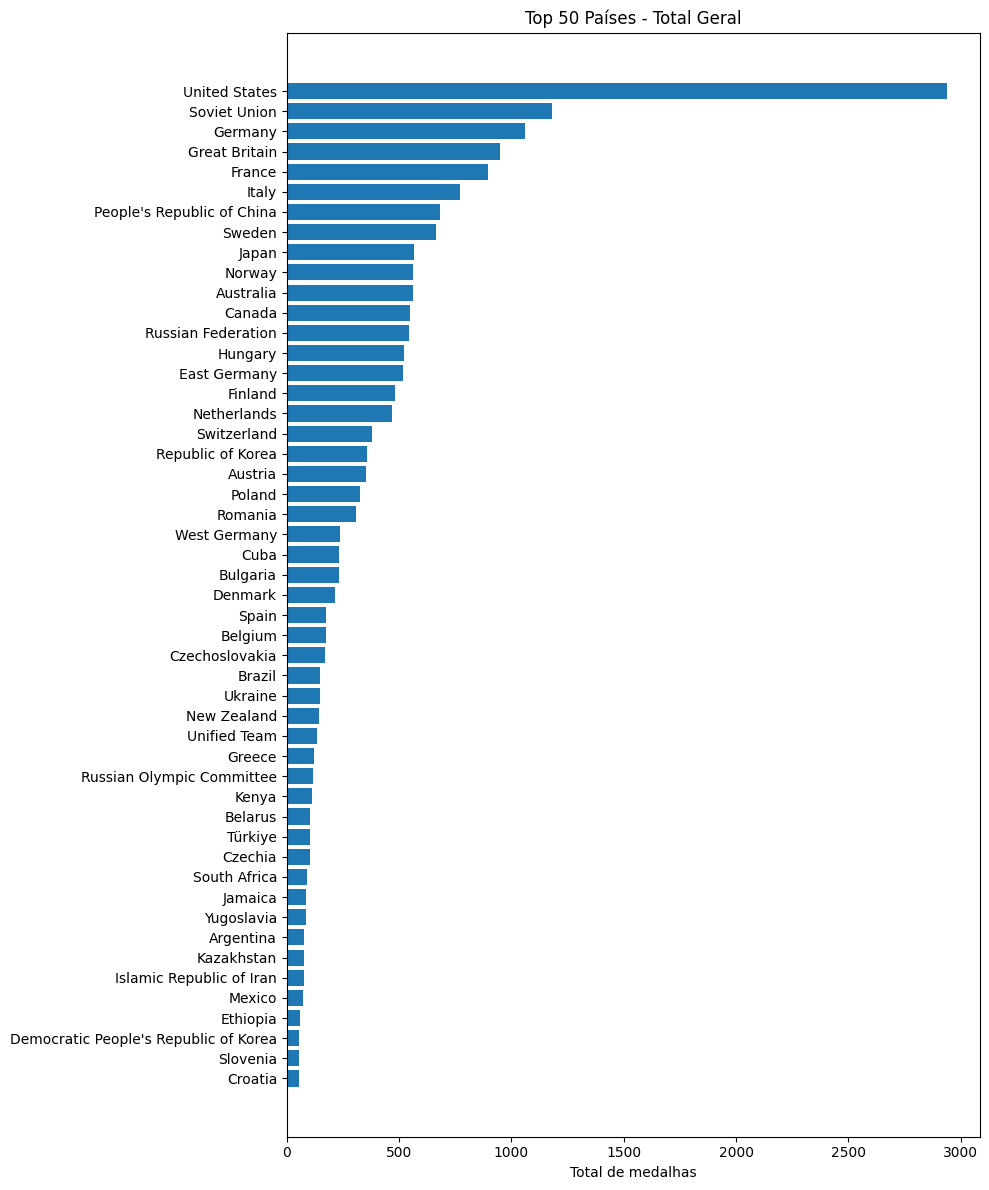

In [72]:
plot_top50(
    top50_summer,
    "Top 50 Países - Jogos de Verão"
)

plot_top50(
    top50_winter,
    "Top 50 Países - Jogos de Inverno"
)

plot_top50(
    top50_total,
    "Top 50 Países - Total Geral"
)

In [73]:
tabela_verao = (
    summer_medals
    .rename(columns={
        "name": "País",
        "total_medals": "Total de Medalhas"
    })
    .reset_index(drop=True)
)

print("Medalhas — Jogos de Verão")
display(tabela_verao)

Medalhas — Jogos de Verão


,País,Total de Medalhas
0,United States,2749
1,Soviet Union,990
2,Great Britain,977
3,France,823
4,Germany,802
...,...,...
157,Sudan,1
158,Turkmenistan,1
159,Tonga,1
160,Togo,1


In [74]:
tabela_inverso = (
    winter_medals
    .rename(columns={
        "name": "País",
        "total_medals": "Total de Medalhas"
    })
    .reset_index(drop=True)
)

print("Medalhas — Jogos de Inverno")
display(tabela_inverso)

Medalhas — Jogos de Inverno


,País,Total de Medalhas
0,Norway,404
1,United States,316
2,Germany,284
3,Austria,249
4,Canada,222
5,Soviet Union,191
6,Sweden,176
7,Finland,175
8,Switzerland,166
9,Netherlands,143


In [75]:
tabela_total = (
    total_medals
    .rename(columns={
        "name": "País",
        "total_medals": "Total de Medalhas"
    })
    .reset_index(drop=True)
)

print("Medalhas — Total Geral")
display(tabela_total)

Medalhas — Total Geral


,País,Total de Medalhas
0,United States,2939
1,Soviet Union,1181
2,Germany,1059
3,Great Britain,950
4,France,897
...,...,...
149,Sudan,1
150,Turkmenistan,1
151,Tonga,1
152,Togo,1
